In [119]:
import pandas as pd
import geopandas 
# import rasterio
# from rasterio.plot import show
import contextily as cx
import folium
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

import statsmodels.api as sm
import statsmodels.formula.api as sm_formula

import h3
import h3pandas
import numpy as np 
import math
import decimal

from shapely import geometry, ops

from scipy import stats

In [ ]:
def compare_variables(df, variables,cmap="inferno",alpha=0.7,legend=True,legend_kwds={'shrink': 0.6}):
    count = len(variables)
    _, axs = plt.subplots(1, count, figsize=(20, 7))
    for var, ax in zip(variables,axs):
        df.plot(
            column=var,
            cmap=cmap,
            alpha=alpha,
            legend=legend,
            legend_kwds=legend_kwds,
            ax=ax
        )
        cx.add_basemap(ax, crs=df.crs, source=cx.providers.CartoDB.Positron, zoom=10)

# Step 1: Import Dataframes

In [121]:
tree_canopy_df = geopandas.read_file("qGIS/h3_07_tree_canopy_overlap.gpkg")
tree_canopy_df = tree_canopy_df.rename(columns={"index":"h3_07"})
print(tree_canopy_df.count())
tree_canopy_df.head()


h3_07          517
canopy_area    517
canopy_pct     517
geometry       517
dtype: int64


,h3_07,canopy_area,canopy_pct,geometry
0,872aa8516ffffff,2.341654e+06,46.369505,"POLYGON ((-77.06863 39.23343, -77.08247 39.226..."
1,872aa8633ffffff,2.781486e+06,55.658016,"POLYGON ((-76.95932 38.73139, -76.97304 38.724..."
2,872aa8426ffffff,2.339924e+06,46.437593,"POLYGON ((-77.02851 39.12646, -77.04233 39.119..."
3,872aa80b2ffffff,2.359590e+06,46.940742,"POLYGON ((-76.79943 39.01152, -76.81325 39.004..."
4,872aa8449ffffff,1.602704e+06,31.971654,"POLYGON ((-76.91643 38.87844, -76.93019 38.871..."


In [122]:
traffic_df = geopandas.read_file("outputs/traffic_h3.gpkg", layer="traffic")
# traffic_df = traffic_df.set_index("h3_07")
print(traffic_df.count())
traffic_df.head()

h3_07                321
AAWDT_2023_median    321
AAWDT_2023_sum       321
AAWDT_2023_mean      321
geometry             321
dtype: int64


,h3_07,AAWDT_2023_median,AAWDT_2023_sum,AAWDT_2023_mean,geometry
0,872aa8080ffffff,4760.0,64000.0,8000.000000,"POLYGON ((-76.75096 38.95962, -76.76477 38.952..."
1,872aa8081ffffff,5324.5,10649.0,5324.500000,"POLYGON ((-76.73482 38.94233, -76.74863 38.935..."
2,872aa8082ffffff,8452.0,8452.0,8452.000000,"POLYGON ((-76.77975 38.95813, -76.79355 38.951..."
3,872aa8084ffffff,2460.0,17204.0,4301.000000,"POLYGON ((-76.7383 38.97841, -76.75212 38.9716..."
4,872aa8085ffffff,10855.0,360550.0,21208.823529,"POLYGON ((-76.72217 38.96111, -76.73598 38.954..."


In [123]:
wssc_alerts_df = geopandas.read_file("outputs/wssc_alerts_h3.gpkg", layer="alerts")
print(wssc_alerts_df.count())
wssc_alerts_df.head()

h3_07       86
count       86
geometry    86
dtype: int64


,h3_07,count,geometry
0,872aa8094ffffff,2,"POLYGON ((-76.81207 38.99271, -76.82588 38.985..."
1,872aa8099ffffff,1,"POLYGON ((-76.78886 38.90328, -76.80265 38.896..."
2,872aa809dffffff,1,"POLYGON ((-76.77623 38.92206, -76.79003 38.915..."
3,872aa80d0ffffff,3,"POLYGON ((-76.71178 38.85295, -76.72556 38.846..."
4,872aa8400ffffff,2,"POLYGON ((-77.06621 39.0699, -77.08001 39.0631..."


# Step 2: Join the dataframes    

In [124]:
print(tree_canopy_df["h3_07"].dtype)
print(traffic_df["h3_07"].dtype)

print(tree_canopy_df.index.dtype)
print(traffic_df.index.dtype)

str
str
int64
int64


In [125]:
joined_df = tree_canopy_df.set_index("h3_07").join(
    traffic_df.set_index("h3_07").drop(columns=["geometry"]), 
    on="h3_07"
    ).join(
        wssc_alerts_df.set_index("h3_07").drop(columns=["geometry"]), on="h3_07")

joined_df.head()

,canopy_area,canopy_pct,geometry,AAWDT_2023_median,AAWDT_2023_sum,AAWDT_2023_mean,count
h3_07,,,,,,,
872aa8516ffffff,2.341654e+06,46.369505,"POLYGON ((-77.06863 39.23343, -77.08247 39.226...",NaN,NaN,NaN,NaN
872aa8633ffffff,2.781486e+06,55.658016,"POLYGON ((-76.95932 38.73139, -76.97304 38.724...",3075.0,3075.0,3075.000000,NaN
872aa8426ffffff,2.339924e+06,46.437593,"POLYGON ((-77.02851 39.12646, -77.04233 39.119...",11089.5,22179.0,11089.500000,NaN
872aa80b2ffffff,2.359590e+06,46.940742,"POLYGON ((-76.79943 39.01152, -76.81325 39.004...",1990.0,1990.0,1990.000000,NaN
872aa8449ffffff,1.602704e+06,31.971654,"POLYGON ((-76.91643 38.87844, -76.93019 38.871...",4153.0,79837.0,11405.285714,NaN


In [126]:
joined_df.to_file("outputs/wssc_alerts_h3_joined.gpkg", layer='alerts', driver="GPKG")

<Axes: xlabel='count', ylabel='Count'>

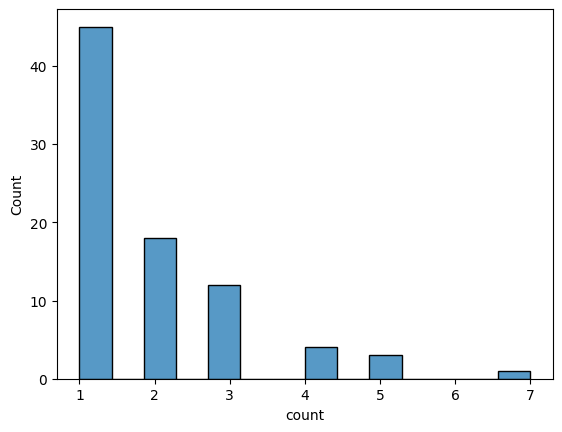

In [127]:
sns.histplot(joined_df["count"])

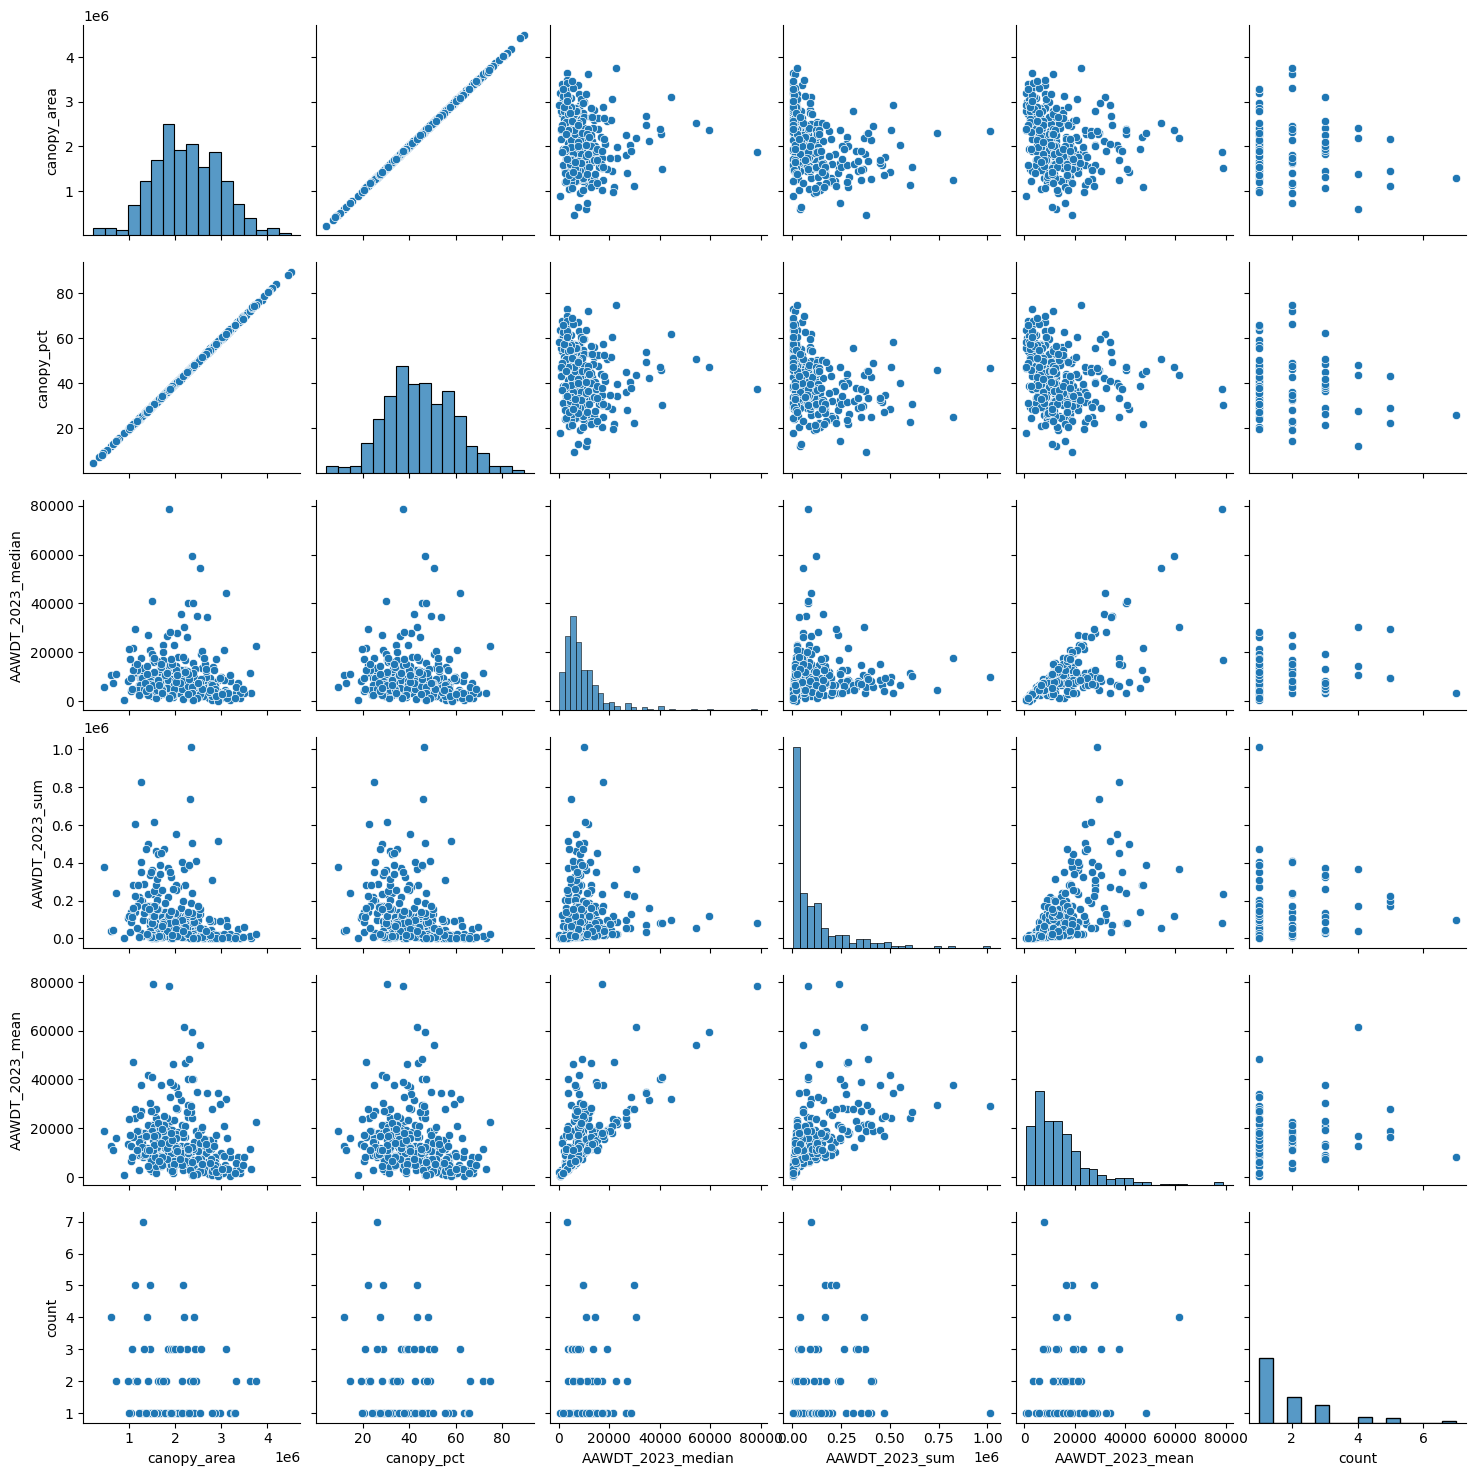

In [128]:
sns.pairplot(joined_df)

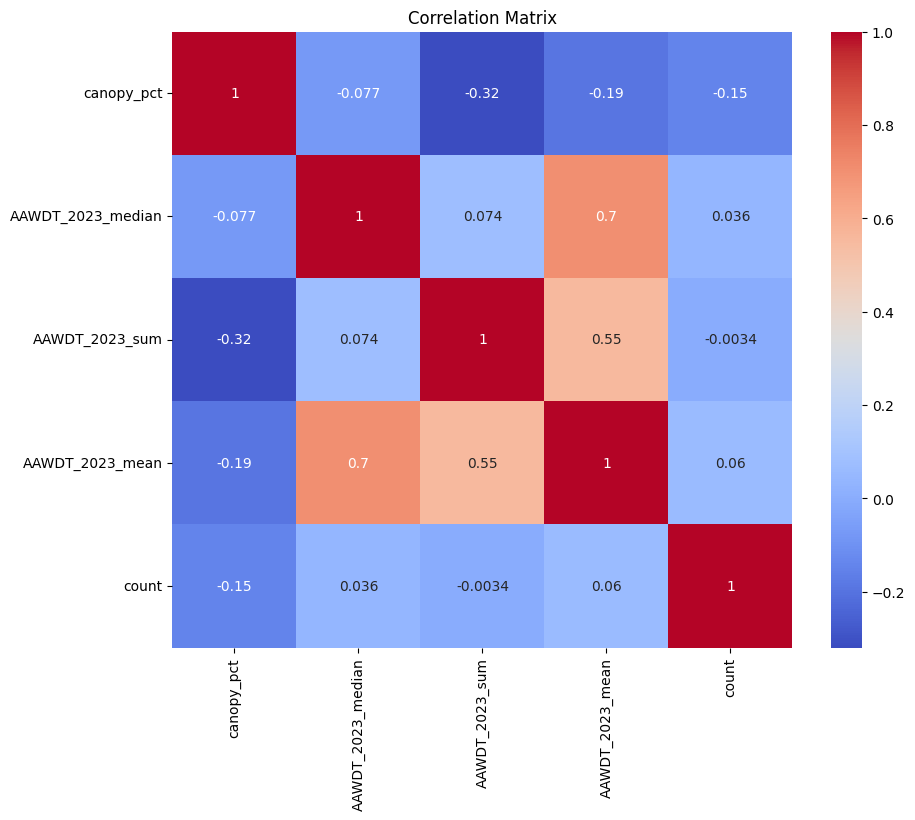

In [129]:
plt.figure(figsize=(10, 8))
sns.heatmap(joined_df.drop(columns=["geometry", "canopy_area"]).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [1]:

# fig, ax = plt.subplots(1, 3, figsize=(20, 7))

variables = ["count", "canopy_pct", "AAWDT_2023_sum"]
compare_variables(joined_df,variables=variables)
# for variable, i in zip(variables, range(3)):
#     joined_df.plot(
#         column=variable,
#         figsize=(10, 10),
#         cmap='inferno',
#         alpha=0.7,
#         legend=True,
#         legend_kwds={'shrink': 0.6},
#         ax=ax[i]
#     )
#     cx.add_basemap(ax[i], crs=joined_df.crs, source=cx.providers.CartoDB.Positron, zoom=10)

NameError: name 'compare_variables' is not defined

# Linear Regression

In [131]:
problem_children = joined_df[joined_df["AAWDT_2023_sum"].isna()][joined_df["count"].isna() == False]
problem_children

/home/emmaf/miniconda3/envs/sewer_repair_data/lib/python3.14/site-packages/geopandas/geodataframe.py:1891: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)


,canopy_area,canopy_pct,geometry,AAWDT_2023_median,AAWDT_2023_sum,AAWDT_2023_mean,count
h3_07,,,,,,,
872aa848cffffff,2.970742e+06,59.081277,"POLYGON ((-77.23539 39.02424, -77.24915 39.017...",NaN,NaN,NaN,1.0
872aa8788ffffff,1.351569e+06,27.026283,"POLYGON ((-77.02029 38.76426, -77.03401 38.757...",NaN,NaN,NaN,1.0
872aa809dffffff,3.287288e+06,65.518205,"POLYGON ((-76.77623 38.92206, -76.79003 38.915...",NaN,NaN,NaN,1.0
872aa8605ffffff,2.382073e+06,47.699091,"POLYGON ((-76.89844 38.69849, -76.91215 38.691...",NaN,NaN,NaN,1.0
872aa8480ffffff,2.865006e+06,56.937691,"POLYGON ((-77.26809 39.05873, -77.28186 39.051...",NaN,NaN,NaN,1.0
872aa80d0ffffff,3.111031e+06,62.095643,"POLYGON ((-76.71178 38.85295, -76.72556 38.846...",NaN,NaN,NaN,3.0
872aa870dffffff,2.413737e+06,48.254502,"POLYGON ((-76.79092 38.77647, -76.80467 38.769...",NaN,NaN,NaN,4.0


In [132]:
m = folium.Map(tiles="CartoDB Positron",scrollWheelZoom=False)

folium.Choropleth(
    geo_data=problem_children.reset_index(),
    data=problem_children.reset_index(),
    columns=["h3_07", "AAWDT_2023_sum"],
    fill_color="inferno",
    line_color=None,
    highlight=True,
    key_on="feature.properties.h3_07",
).add_to(m)


m.fit_bounds(m.get_bounds())
print(m.get_bounds())

m

[[38.674533624939166, -77.28185957768514], [39.05873200040907, -76.69569037452759]]


In [133]:
# TODO: There are some values where AAWDT_2023 is NA but count is not, would like to find a fill for AAWDT_2023 based on surrounding hexes or something
alert_df = joined_df[joined_df["AAWDT_2023_sum"].isna() == False].drop(columns=["canopy_area"]).fillna(0).reset_index()
alert_df.head()


,h3_07,canopy_pct,geometry,AAWDT_2023_median,AAWDT_2023_sum,AAWDT_2023_mean,count
0,872aa8633ffffff,55.658016,"POLYGON ((-76.95932 38.73139, -76.97304 38.724...",3075.0,3075.0,3075.000000,0.0
1,872aa8426ffffff,46.437593,"POLYGON ((-77.02851 39.12646, -77.04233 39.119...",11089.5,22179.0,11089.500000,0.0
2,872aa80b2ffffff,46.940742,"POLYGON ((-76.79943 39.01152, -76.81325 39.004...",1990.0,1990.0,1990.000000,0.0
3,872aa8449ffffff,31.971654,"POLYGON ((-76.91643 38.87844, -76.93019 38.871...",4153.0,79837.0,11405.285714,0.0
4,872aa8088ffffff,38.644341,"POLYGON ((-76.73134 38.90627, -76.74514 38.899...",5005.0,45310.0,6472.857143,0.0


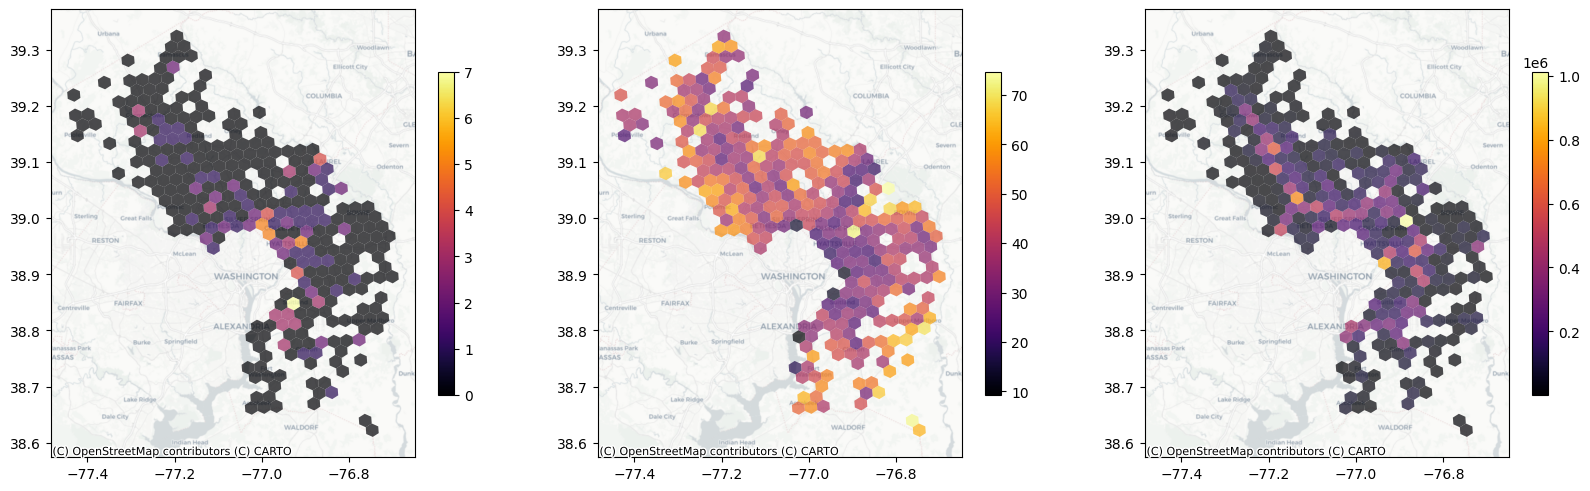

In [134]:
variables = ["count", "canopy_pct", "AAWDT_2023_sum"]
compare_variables(alert_df,variables=variables)

In [135]:
# H0: No correlation between Canopy and traffic vs alerts

# H1: Some correlation


# Linear regression
X = alert_df[["canopy_pct", "AAWDT_2023_sum"]]
y = alert_df["count"]

reg = sm.OLS(y, sm.add_constant(X)).fit()
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  count   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     8.300
Date:                Mon, 04 May 2026   Prob (F-statistic):           0.000309
Time:                        14:34:12   Log-Likelihood:                -435.19
No. Observations:                 310   AIC:                             876.4
Df Residuals:                     307   BIC:                             887.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.9582      0.226      4.246      0.000       0.514       1.402
canopy_pct        -0.0138      0.005     -2.872      0.004      -0.023      -0.004
AAWDT_2023_sum  7.359e-07   4.05e-07      1.819      0.070   -6.01e-08    1.53e-06
==============================================================================
Omnibus:                      200.522   Durbin-Watson:                   1.997
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1474.177
Skew:                           2.715   Prob(JB):                         0.00
Kurtosis:                      12.200   Cond. No.                     7.31e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.31e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [136]:
# Linear regression
X = alert_df[["canopy_pct", "AAWDT_2023_sum"]]
y = alert_df["count"]

reg = sm.OLS(y, sm.add_constant(X)).fit()
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  count   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     8.300
Date:                Mon, 04 May 2026   Prob (F-statistic):           0.000309
Time:                        14:34:12   Log-Likelihood:                -435.19
No. Observations:                 310   AIC:                             876.4
Df Residuals:                     307   BIC:                             887.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.9582      0.226      4.246      0.000       0.514       1.402
canopy_pct        -0.0138      0.005     -2.872      0.004      -0.023      -0.004
AAWDT_2023_sum  7.359e-07   4.05e-07      1.819      0.070   -6.01e-08    1.53e-06
==============================================================================
Omnibus:                      200.522   Durbin-Watson:                   1.997
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1474.177
Skew:                           2.715   Prob(JB):                         0.00
Kurtosis:                      12.200   Cond. No.                     7.31e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.31e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [137]:
gaussian_model = sm.GLM(y, sm.add_constant(X), family=sm.families.Gaussian())
gaussian_result = gaussian_model.fit()
print(gaussian_result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  count   No. Observations:                  310
Model:                            GLM   Df Residuals:                      307
Model Family:                Gaussian   Df Model:                            2
Link Function:               Identity   Scale:                         0.97971
Method:                          IRLS   Log-Likelihood:                -435.19
Date:                Mon, 04 May 2026   Deviance:                       300.77
Time:                        14:34:12   Pearson chi2:                     301.
No. Iterations:                     3   Pseudo R-squ. (CS):            0.05218
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.9582      0.226      4.

In [138]:
gamma_model = sm.GLM(y, sm.add_constant(X), family=sm.families.Gamma())
gamma_result = gamma_model.fit()
print(gamma_result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  count   No. Observations:                  310
Model:                            GLM   Df Residuals:                      307
Model Family:                   Gamma   Df Model:                            2
Link Function:           InversePower   Scale:                          5.5097
Method:                          IRLS   Log-Likelihood:                    inf
Date:                Mon, 04 May 2026   Deviance:                       16839.
Time:                        14:34:12   Pearson chi2:                 1.69e+03
No. Iterations:                    11   Pseudo R-squ. (CS):                nan
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.6647      0.590      1.

/home/emmaf/miniconda3/envs/sewer_repair_data/lib/python3.14/site-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The InversePower link function does not respect the domain of the Gamma family.
  warnings.warn((f"The {type(family.link).__name__} link function "
/home/emmaf/miniconda3/envs/sewer_repair_data/lib/python3.14/site-packages/statsmodels/genmod/families/family.py:812: RuntimeWarning: divide by zero encountered in log
  ll_obs -= special.gammaln(weight_scale) + np.log(endog)
/home/emmaf/miniconda3/envs/sewer_repair_data/lib/python3.14/site-packages/statsmodels/genmod/generalized_linear_model.py:1891: RuntimeWarning: invalid value encountered in scalar subtract
  prsq = 1 - np.exp((self.llnull - self.llf) * (2 / self.nobs))


In [139]:
poisson_model = sm.GLM(y, sm.add_constant(X), family=sm.families.Poisson())
poisson_result = poisson_model.fit()
print(poisson_result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  count   No. Observations:                  310
Model:                            GLM   Df Residuals:                      307
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -300.83
Date:                Mon, 04 May 2026   Deviance:                       417.66
Time:                        14:34:12   Pearson chi2:                     625.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1063
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.3743      0.310      1.

# Let's try Global Spatial Autocorrelation

Specifically Global Moran's I, using code from [here](https://github.com/uber/h3-py-notebooks/blob/173be2e1/notebooks/urban_analytics.ipynb#L474-L487)

In [140]:
import h3
import h3pandas
import numpy as np 

from shapely import geometry, ops

In [141]:
def prepare_geodataframe_GMI(df_aggreg, target_col = "count", num_rings = 2, 
                             flag_debug = False, flag_return_gdf = True):
    """Prepares dataframe for Global Moran's I computation, namely by
       computing z-score and geometry object for each row of the input df_aggreg"""

    df_aux = df_aggreg.copy()

    # get resolution from the hex_id of the first row (assume all the same in df_aggreg)
    # res = h3.get_resolution(df_aux.iloc[0]["h3_07"])
    res = 7
    mean_count_cell = df_aux[target_col].mean()
    stddev_count_cell = df_aux[target_col].std(ddof = 0)

    if flag_debug is True:
        msg_ = "Average number of count per H3 cell at resolution {} : {}"
        print(msg_.format(res, mean_count_cell))

    # z_score column
    df_aux["z_score"] = (df_aux[target_col] - mean_count_cell) / stddev_count_cell

    # list of cell ids on hollow rings
    for i in range(1, num_rings + 1):
        df_aux["ring{}".format(i)] = df_aux["h3_07"].apply(lambda x:
                                                            list(h3.grid_ring(h = x,
                                                                             k = i)))

    if flag_return_gdf is True:
        # make shapely geometry objects out of geojson
        df_aux["geometry_shp"] = df_aux["geometry"].apply(
                                              lambda x:
                                              geometry.Polygon(geometry.shape(x)))
        df_aux.rename(columns={"geometry": "geometry_geojson"}, inplace=True)

        geom = df_aux["geometry_shp"]
        df_aux.drop(columns=["geometry_shp"], inplace = True)
        gdf_aux = geopandas.GeoDataFrame(df_aux, crs="EPSG:4326", geometry=geom)

        return gdf_aux
    else:
        
        return df_aux


In [142]:
# for res in dict_filled_aggreg:
#     gdf_gmi_prepared = prepare_geodataframe_GMI(dict_filled_aggreg[res],
#                                                 num_rings = 1,
#                                                 flag_debug = True)
#     dict_prepared_GMI[res] = gdf_gmi_prepared

alert_prepared_GMI_df = prepare_geodataframe_GMI(alert_df.reset_index(), num_rings = 1, flag_debug=True)
alert_prepared_GMI_df.head()

Average number of count per H3 cell at resolution 7 : 0.4612903225806452


,index,h3_07,canopy_pct,geometry_geojson,AAWDT_2023_median,AAWDT_2023_sum,AAWDT_2023_mean,count,z_score,ring1,geometry
0,0,872aa8633ffffff,55.658016,"POLYGON ((-76.95932 38.73139, -76.97304 38.724...",3075.0,3075.0,3075.000000,0.0,-0.456143,"[872aa8630ffffff, 872aa8632ffffff, 872aa8614ff...","POLYGON ((-76.95932 38.73139, -76.97304 38.724..."
1,1,872aa8426ffffff,46.437593,"POLYGON ((-77.02851 39.12646, -77.04233 39.119...",11089.5,22179.0,11089.500000,0.0,-0.456143,"[872aa8519ffffff, 872aa851bffffff, 872aa8435ff...","POLYGON ((-77.02851 39.12646, -77.04233 39.119..."
2,2,872aa80b2ffffff,46.940742,"POLYGON ((-76.79943 39.01152, -76.81325 39.004...",1990.0,1990.0,1990.000000,0.0,-0.456143,"[872aa80b6ffffff, 872aa854dffffff, 872aa8549ff...","POLYGON ((-76.79943 39.01152, -76.81325 39.004..."
3,3,872aa8449ffffff,31.971654,"POLYGON ((-76.91643 38.87844, -76.93019 38.871...",4153.0,79837.0,11405.285714,0.0,-0.456143,"[872aa844dffffff, 872aa8448ffffff, 872aa844bff...","POLYGON ((-76.91643 38.87844, -76.93019 38.871..."
4,4,872aa8088ffffff,38.644341,"POLYGON ((-76.73134 38.90627, -76.74514 38.899...",5005.0,45310.0,6472.857143,0.0,-0.456143,"[872aa808cffffff, 872aa808effffff, 872aa808aff...","POLYGON ((-76.73134 38.90627, -76.74514 38.899..."


In [143]:
def compute_spatial_lags_using_H3(gdf_prepared, variable_col = "z_score"):
    """Computes spatial lags for an input dataframe which was prepared with method
       prepare_geodataframe_GMI"""

    gdf_aux = gdf_prepared.copy()
    gdf_aux["spatial_lag"] = np.nan

    # for better performance on lookup
    dict_z = dict(zip(gdf_prepared["h3_07"], gdf_prepared[variable_col]))
    dict_ring1 = dict(zip(gdf_prepared["h3_07"], gdf_prepared["ring1"]))

    # in step 2, for each hexagon get its hollow ring 1
    for hex_id in dict_z.keys():
        list_hexes_ring = dict_ring1[hex_id]

        # filter and keep only the hexagons of this ring that have a value in our dataset
        hexes_ring_with_value = [item for item in list_hexes_ring if item in dict_z]
        num_hexes_ring_with_value = len(hexes_ring_with_value)

        if num_hexes_ring_with_value > 0:
            # ensure row-standardized weights
            wij_adjusted = 1 / num_hexes_ring_with_value    

            sum_neighbors = sum([dict_z[k] for k in hexes_ring_with_value])
            # spatial lag
            spatial_lag = wij_adjusted * sum_neighbors

            gdf_aux.loc[gdf_aux["h3_07"] == hex_id, "spatial_lag"] = spatial_lag

    return gdf_aux

In [144]:
# dict_z = dict(zip(alert_prepared_GMI_df["h3_07"], alert_prepared_GMI_df["z_score"]))
# dict_ring1 = dict(zip(alert_prepared_GMI_df["h3_07"], alert_prepared_GMI_df["ring1"]))
# for hex_id in dict_z.keys():
#     list_hexes_ring = dict_ring1[hex_id]
#     hexes_ring_with_value = [item for item in list_hexes_ring if item in dict_z]
#     if len(hexes_ring_with_value) == 0:
#         print(hex_id)


In [145]:


alert_spatial_lags_df = compute_spatial_lags_using_H3(gdf_prepared = alert_prepared_GMI_df,
                                                   variable_col = "z_score")

alert_spatial_lags_df.head()



,index,h3_07,canopy_pct,geometry_geojson,AAWDT_2023_median,AAWDT_2023_sum,AAWDT_2023_mean,count,z_score,ring1,geometry,spatial_lag
0,0,872aa8633ffffff,55.658016,"POLYGON ((-76.95932 38.73139, -76.97304 38.724...",3075.0,3075.0,3075.000000,0.0,-0.456143,"[872aa8630ffffff, 872aa8632ffffff, 872aa8614ff...","POLYGON ((-76.95932 38.73139, -76.97304 38.724...",-0.456143
1,1,872aa8426ffffff,46.437593,"POLYGON ((-77.02851 39.12646, -77.04233 39.119...",11089.5,22179.0,11089.500000,0.0,-0.456143,"[872aa8519ffffff, 872aa851bffffff, 872aa8435ff...","POLYGON ((-77.02851 39.12646, -77.04233 39.119...",-0.456143
2,2,872aa80b2ffffff,46.940742,"POLYGON ((-76.79943 39.01152, -76.81325 39.004...",1990.0,1990.0,1990.000000,0.0,-0.456143,"[872aa80b6ffffff, 872aa854dffffff, 872aa8549ff...","POLYGON ((-76.79943 39.01152, -76.81325 39.004...",-0.126529
3,3,872aa8449ffffff,31.971654,"POLYGON ((-76.91643 38.87844, -76.93019 38.871...",4153.0,79837.0,11405.285714,0.0,-0.456143,"[872aa844dffffff, 872aa8448ffffff, 872aa844bff...","POLYGON ((-76.91643 38.87844, -76.93019 38.871...",1.521541
4,4,872aa8088ffffff,38.644341,"POLYGON ((-76.73134 38.90627, -76.74514 38.899...",5005.0,45310.0,6472.857143,0.0,-0.456143,"[872aa808cffffff, 872aa808effffff, 872aa808aff...","POLYGON ((-76.73134 38.90627, -76.74514 38.899...",-0.456143


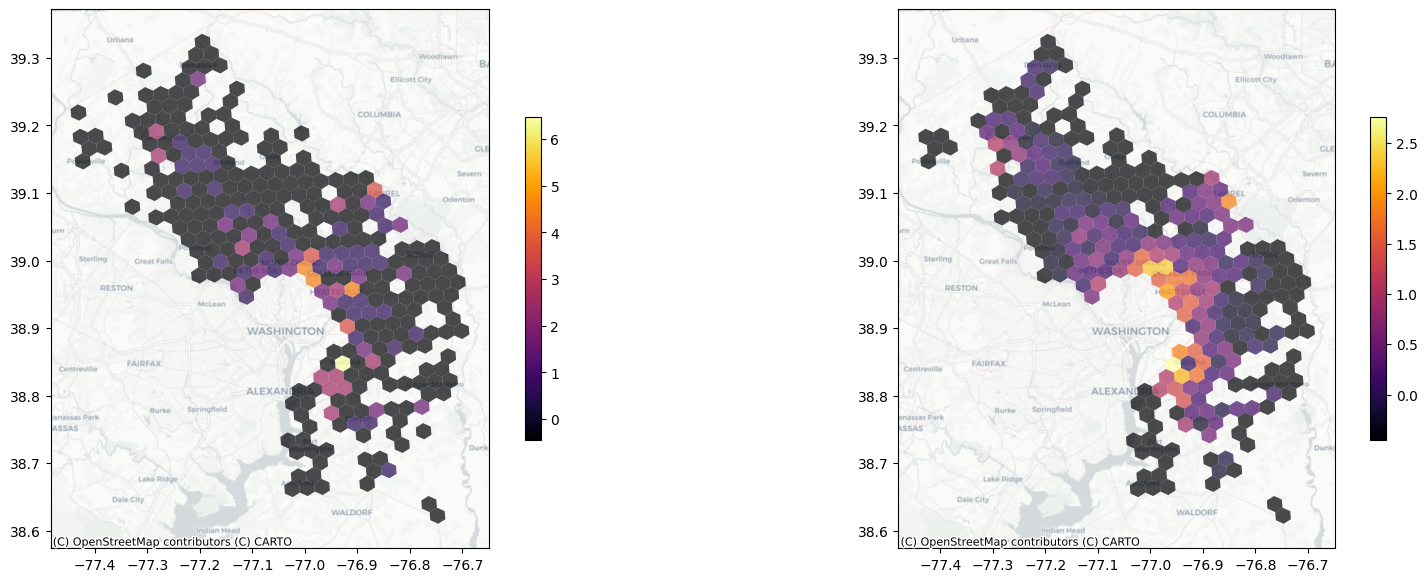

In [146]:
compare_variables(alert_spatial_lags_df,variables=["z_score","spatial_lag"])

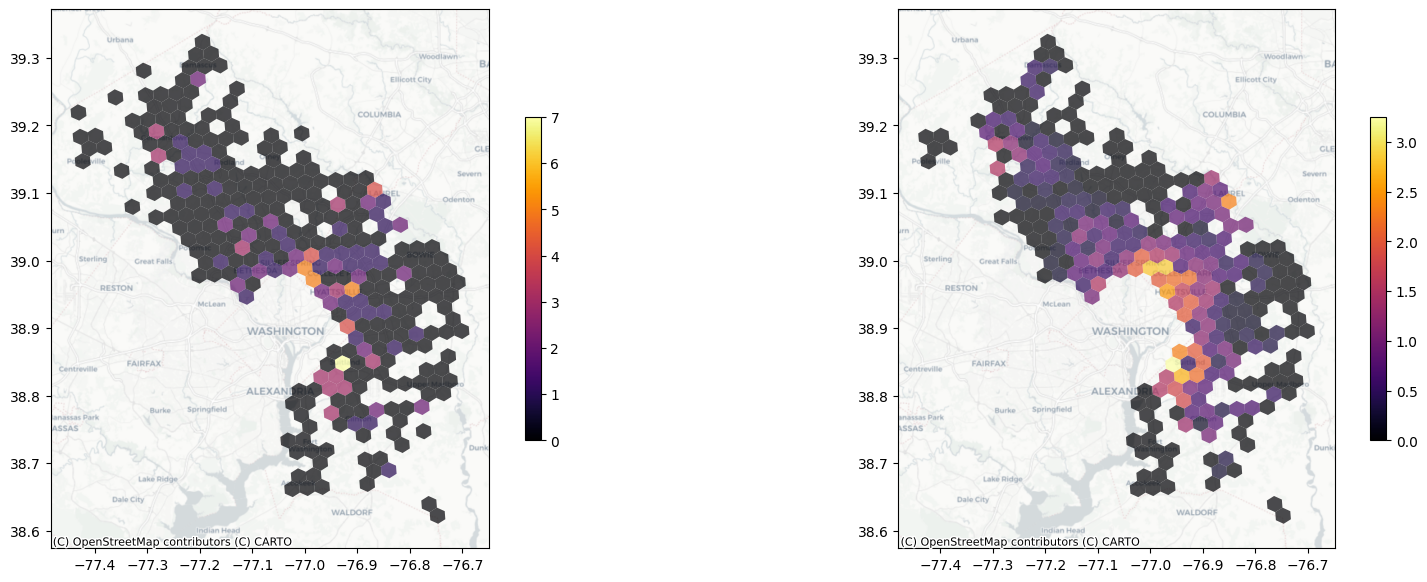

In [147]:
alert_spatial_lags_df = compute_spatial_lags_using_H3(gdf_prepared = alert_prepared_GMI_df,
                                                   variable_col = "count")

compare_variables(alert_spatial_lags_df, variables=["count","spatial_lag"])

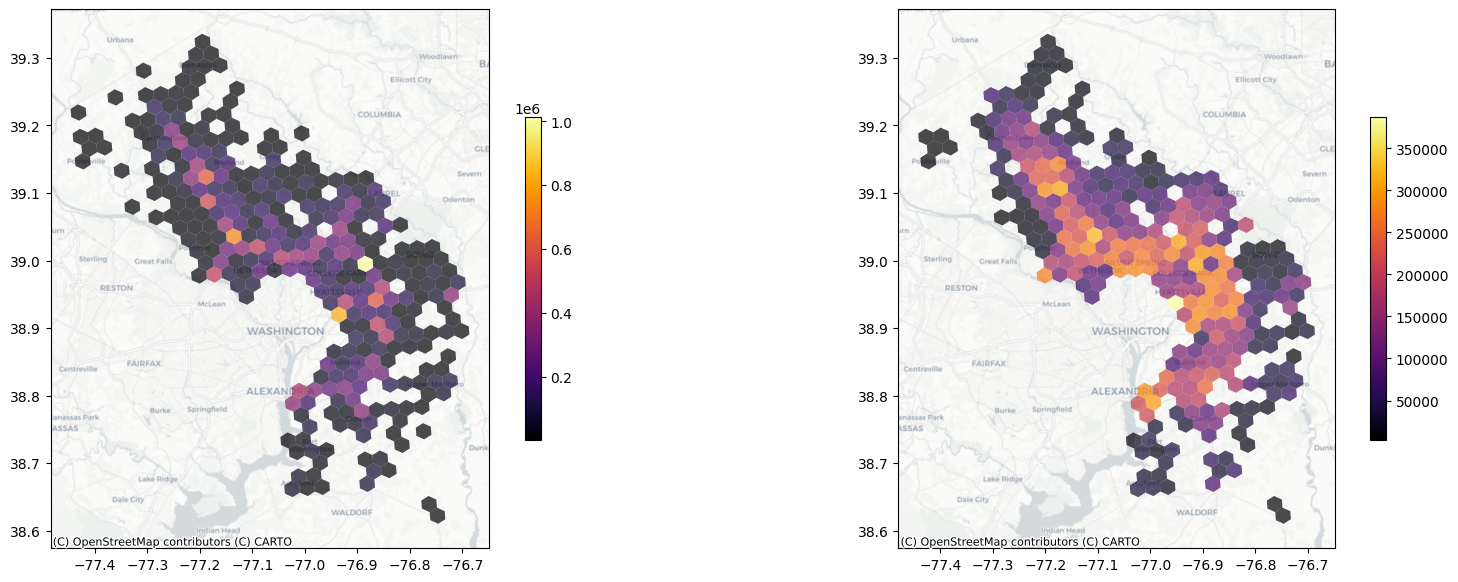

In [148]:
traffic_spatial_lags_df = compute_spatial_lags_using_H3(gdf_prepared = alert_prepared_GMI_df,
                                                   variable_col = "AAWDT_2023_sum")

compare_variables(traffic_spatial_lags_df, variables=["AAWDT_2023_sum","spatial_lag"])

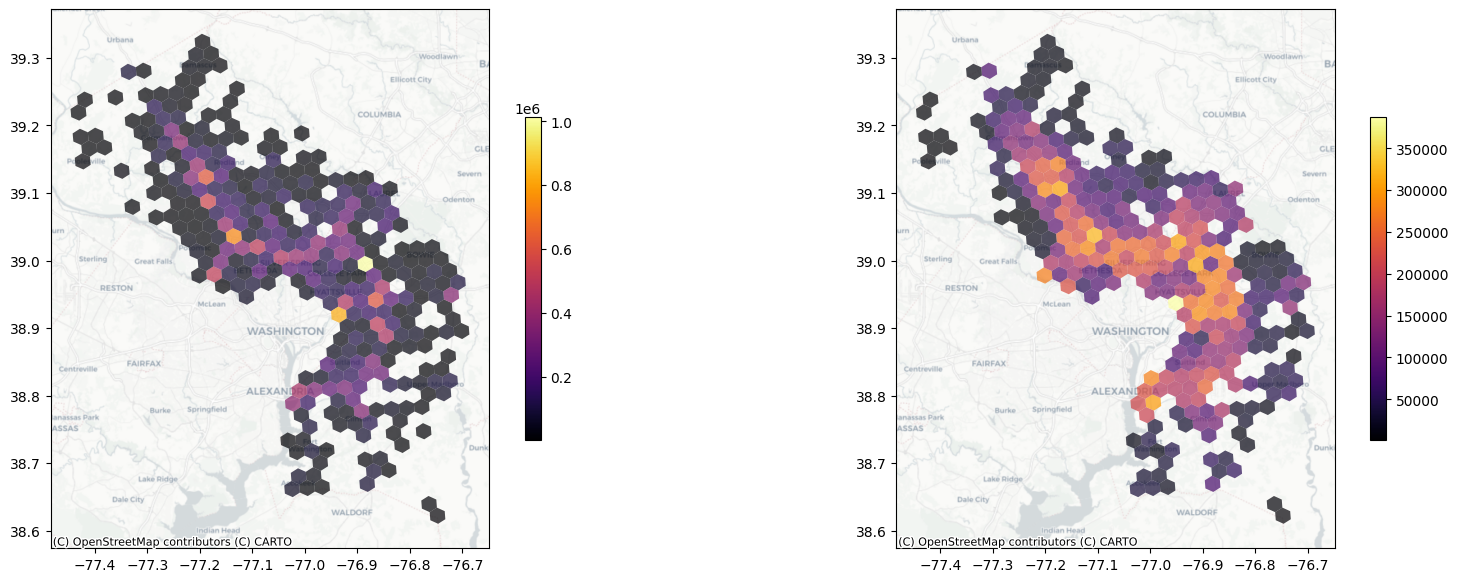

In [149]:
traffic_GMI_df = prepare_geodataframe_GMI(traffic_df,"AAWDT_2023_sum")
traffic_spatial_lags_df = compute_spatial_lags_using_H3(gdf_prepared = traffic_GMI_df,
                                                   variable_col = "AAWDT_2023_sum")
compare_variables(traffic_spatial_lags_df, variables=["AAWDT_2023_sum","spatial_lag"])

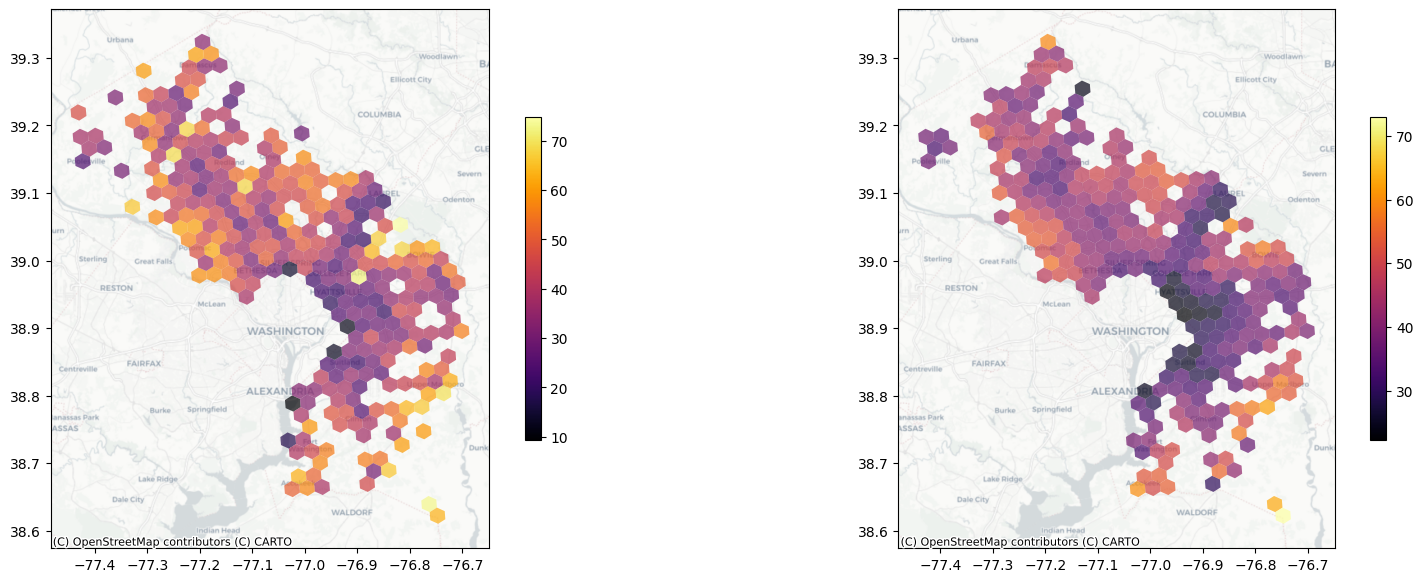

In [150]:
canopy_spatial_lags_df = compute_spatial_lags_using_H3(gdf_prepared = alert_prepared_GMI_df,
                                                   variable_col = "canopy_pct")

compare_variables(canopy_spatial_lags_df, variables=["canopy_pct","spatial_lag"])

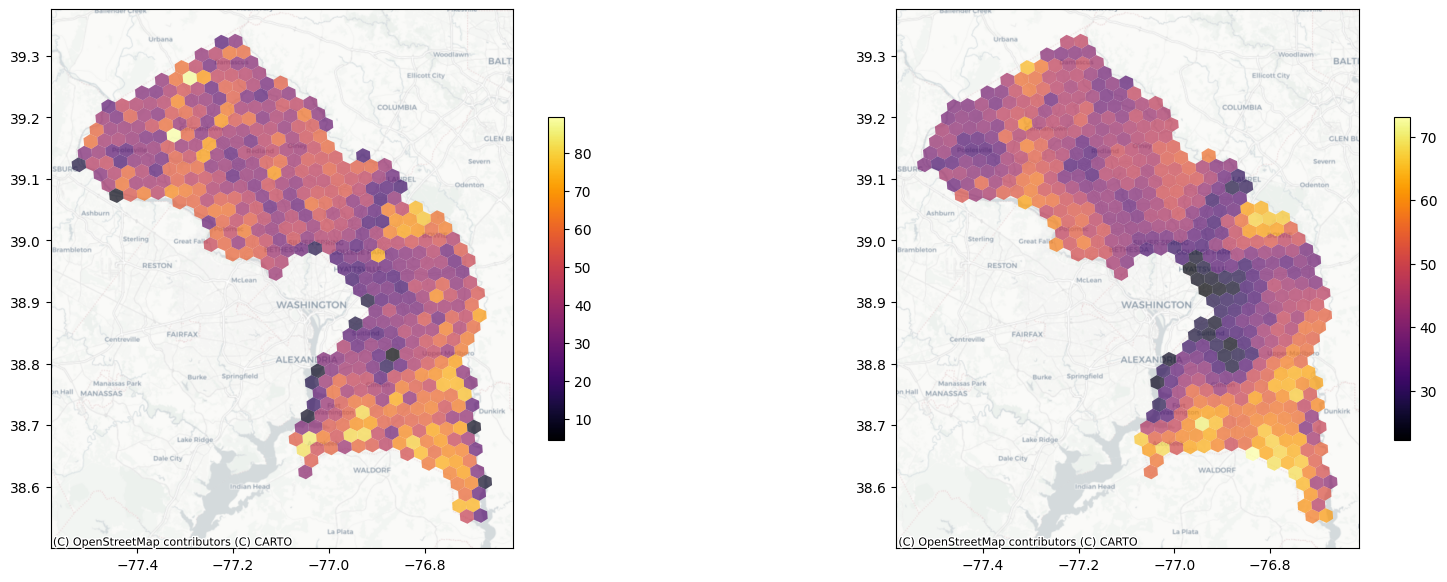

In [151]:
tree_canopy_GMI_df = prepare_geodataframe_GMI(tree_canopy_df,"canopy_pct")
canopy_spatial_lags_df = compute_spatial_lags_using_H3(gdf_prepared = tree_canopy_GMI_df,
                                                   variable_col = "canopy_pct")
compare_variables(canopy_spatial_lags_df, variables=["canopy_pct","spatial_lag"])

In [152]:
result = sm_formula.ols(formula = "spatial_lag ~ z_score", 
                        data = alert_spatial_lags_df).fit()

params = result.params.to_dict()
print(params, "\n")
slope = params["z_score"]
print("Global Moran'I approximated by slope of the regression line:", slope)
print("\n----------------------------------------------------------------\n")

print(result.summary())



{'Intercept': 0.4746421148828001, 'z_score': 0.19838353984420645} 

Global Moran'I approximated by slope of the regression line: 0.19838353984420645

----------------------------------------------------------------

                            OLS Regression Results                            
Dep. Variable:            spatial_lag   R-squared:                       0.102
Model:                            OLS   Adj. R-squared:                  0.099
Method:                 Least Squares   F-statistic:                     34.11
Date:                Mon, 04 May 2026   Prob (F-statistic):           1.35e-08
Time:                        14:41:10   Log-Likelihood:                -272.45
No. Observations:                 303   AIC:                             548.9
Df Residuals:                     301   BIC:                             556.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                    

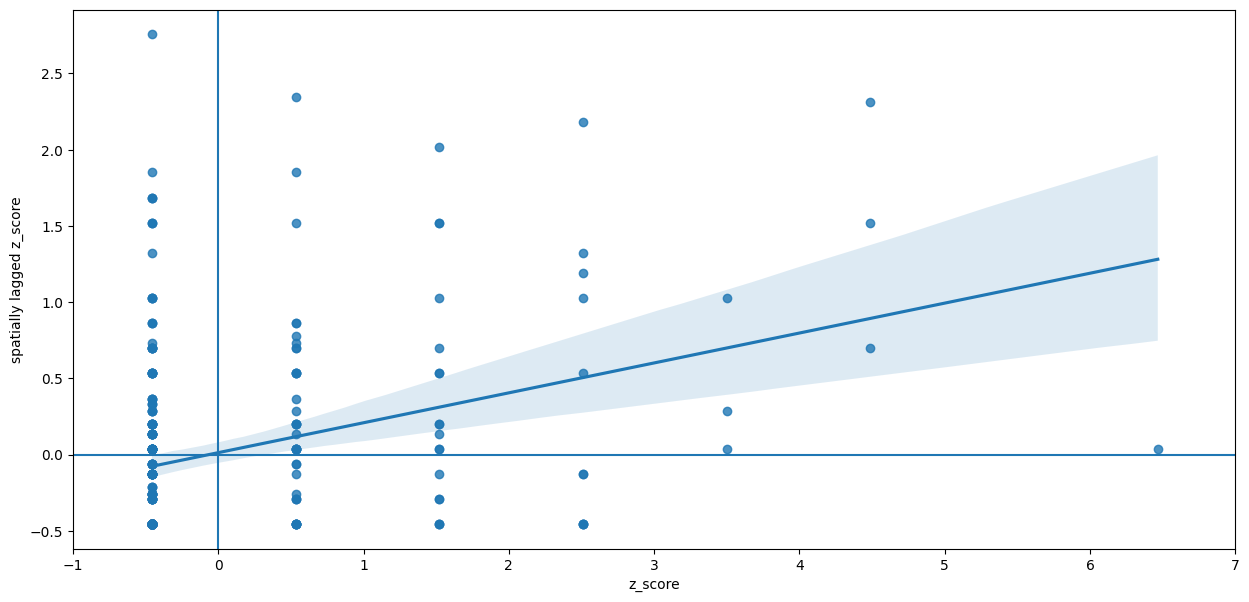

In [153]:
# plot
fig, ax = plt.subplots(1, 1, figsize=(15, 7))
sns.regplot(x = "z_score", y = "spatial_lag", data = spatial_lags_df, ax = ax)
ax.axhline(0.0)
ax.axvline(0.0)

x_min = math.floor(spatial_lags_df["z_score"].min())
x_max = math.ceil(spatial_lags_df["z_score"].max())

ax.set_xlim(x_min, x_max)
ax.set_xlabel("z_score")
ax.set_ylabel("spatially lagged z_score");



In [154]:
def compute_Global_Moran_I_using_H3(gdf_prepared, variable_col = "z_score"):
    """Computes Global Moran I for an input dataframe which was prepared with method
       prepare_geodataframe_GMI"""

    S_wijzizj = 0
    S_wij = gdf_prepared.shape[0]

    # for better performance on lookup
    dict_z = dict(zip(gdf_prepared["h3_07"], gdf_prepared[variable_col]))
    dict_ring1 = dict(zip(gdf_prepared["h3_07"], gdf_prepared["ring1"]))

    # now, in step 2, for each hexagon get its hollow ring 1
    for hex_id in dict_z.keys():
        zi = dict_z[hex_id]
        list_hexes_ring = dict_ring1[hex_id]

        # filter and keep only the hexagons of this ring that have a value in our dataset
        hexes_ring_with_value = [item for item in list_hexes_ring if item in dict_z]
        num_hexes_ring_with_value = len(hexes_ring_with_value)

        if num_hexes_ring_with_value > 0:
            # ensure row-standardized weights
            wij_adjusted = 1 / num_hexes_ring_with_value
            
            # update sum
            sum_neighbors = sum([dict_z[k] for k in hexes_ring_with_value])
            S_wijzizj += wij_adjusted * zi * sum_neighbors

    GMI = S_wijzizj / S_wij
    return GMI

In [155]:
def reshuffle_and_recompute_GMI(gdf_prepared, variable_col = "z_score",
                                num_permut = 999, I_observed = None,
                                alpha = 0.005, alternative = "greater",
                                flag_plot = True, flag_verdict = True):
    """Permutation inference with number of permutations given by num_permut and
       pseudo significance level specified by alpha"""

    gdf_aggreg_reshuff = gdf_prepared.copy()
    list_reshuff_I = []

    for i in range(num_permut):
        # simulate by reshuffling column
        gdf_aggreg_reshuff[variable_col] = np.random.permutation(
                                             gdf_aggreg_reshuff[variable_col].values)

        I_reshuff = compute_Global_Moran_I_using_H3(gdf_prepared = gdf_aggreg_reshuff)
        list_reshuff_I.append(I_reshuff)

    # for hypothesis testing
    list_reshuff_I.append(I_observed)

    # empirical CDF
    ecdf_GMI = sm.distributions.empirical_distribution.ECDF(list_reshuff_I, side = "left")

    percentile_observedI = stats.percentileofscore(list_reshuff_I,
                                                   I_observed,
                                                   kind='strict')
    # note: use decimal to avoid 99.9 / 100 = 0.9990000000000001
    percentile_observedI_ = float(str(decimal.Decimal(str(percentile_observedI)) / 100))

    try:
        assert(ecdf_GMI(I_observed) == percentile_observedI_)
    except Exception:
        pass
        # print(ecdf_GMI(I_observed), " vs ", percentile_observedI_)

    msg_reject_H0 = "P_sim = {:3f} , we can reject H0"
    msg_failtoreject_H0 = "P_sim = {:3f} , we fail to reject H0 under alternative {}"
        
    if alternative == "greater":
        pseudo_p_value = 1 - ecdf_GMI(I_observed)
        if flag_verdict is True:
            if pseudo_p_value < alpha:
                print(msg_reject_H0.format(pseudo_p_value))
            else:
                print(msg_failtoreject_H0.format(pseudo_p_value, alternative))
    elif alternative == "less":
        pseudo_p_value = ecdf_GMI(I_observed)
        if flag_verdict is True:
            if pseudo_p_value < alpha:
                print(msg_reject_H0.format(pseudo_p_value))
            else:
                print(msg_failtoreject_H0.format(pseudo_p_value, alternative))
    elif alternative == "two-tailed":
        pseudo_p_value_greater = 1 - ecdf_GMI(I_observed)
        pseudo_p_value_less = ecdf_GMI(I_observed)
        pseudo_p_value = min(pseudo_p_value_greater, pseudo_p_value_less)
        
        if flag_verdict is True:
            if (pseudo_p_value_greater < alpha/2):
                print(msg_reject_H0.format(pseudo_p_value_greater))
            elif (pseudo_p_value_less < alpha/2):
                print(msg_reject_H0.format(pseudo_p_value_less))
            else:
                pseudo_p_value = min(pseudo_p_value_greater, pseudo_p_value_less)
                print(msg_failtoreject_H0.format(pseudo_p_value, alternative))
        
    if flag_plot is True:
        fig, ax = plt.subplots(1, 2, figsize=(20, 7),
                               gridspec_kw={'width_ratios': [2, 3]})
        gdf_prepared.plot(column=variable_col, cmap= "viridis", ax=ax[0], legend=False)

        ax[1].hist(list_reshuff_I, density=True, bins=50)
        ax[1].axvline(I_observed, color = 'red', linestyle = '--', linewidth = 3)
        fig.tight_layout()
        
    return pseudo_p_value 


In [156]:
gmi_results = compute_Global_Moran_I_using_H3(gdf_prepared = alert_prepared_GMI_df)
print("I =", gmi_results)

I = 0.19538430677102855


P_sim = 0.001000 , we can reject H0


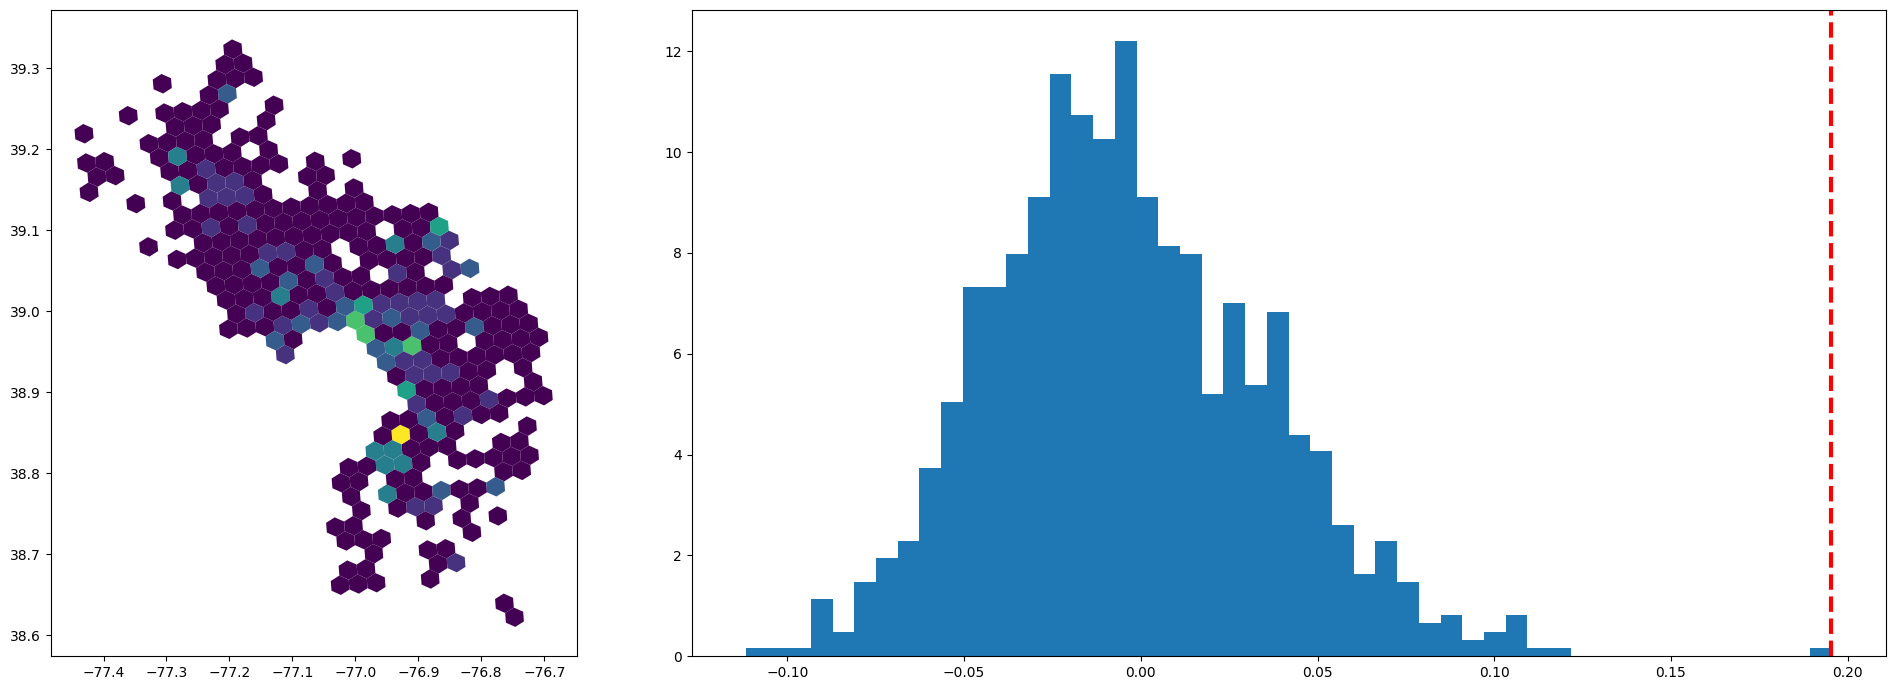

In [157]:
p_sim = reshuffle_and_recompute_GMI(gdf_prepared = alert_prepared_GMI_df,   
                                    num_permut = 999,                            
                                    I_observed = gmi_results,
                                    alternative = "two-tailed",
                                    flag_plot = True)

In [159]:
traffic_prepared_GMI_df = prepare_geodataframe_GMI(alert_df.reset_index(), target_col="AAWDT_2023_sum", num_rings = 1, flag_debug=True)
traffic_spatial_lags_df = compute_spatial_lags_using_H3(gdf_prepared = traffic_prepared_GMI_df,
                                                   variable_col = "z_score")

result = sm_formula.ols(formula = "spatial_lag ~ z_score", 
                        data = traffic_spatial_lags_df).fit()

params = result.params.to_dict()
print(params, "\n")
slope = params["z_score"]
print("Global Moran'I approximated by slope of the regression line:", slope)
print("\n----------------------------------------------------------------\n")

print(result.summary())

Average number of count per H3 cell at resolution 7 : 107904.8129032258
{'Intercept': 0.030695824530535827, 'z_score': 0.2881237220378684} 

Global Moran'I approximated by slope of the regression line: 0.2881237220378684

----------------------------------------------------------------

                            OLS Regression Results                            
Dep. Variable:            spatial_lag   R-squared:                       0.224
Model:                            OLS   Adj. R-squared:                  0.222
Method:                 Least Squares   F-statistic:                     87.05
Date:                Mon, 04 May 2026   Prob (F-statistic):           2.39e-18
Time:                        14:41:53   Log-Likelihood:                -242.63
No. Observations:                 303   AIC:                             489.3
Df Residuals:                     301   BIC:                             496.7
Df Model:                           1                                         
C

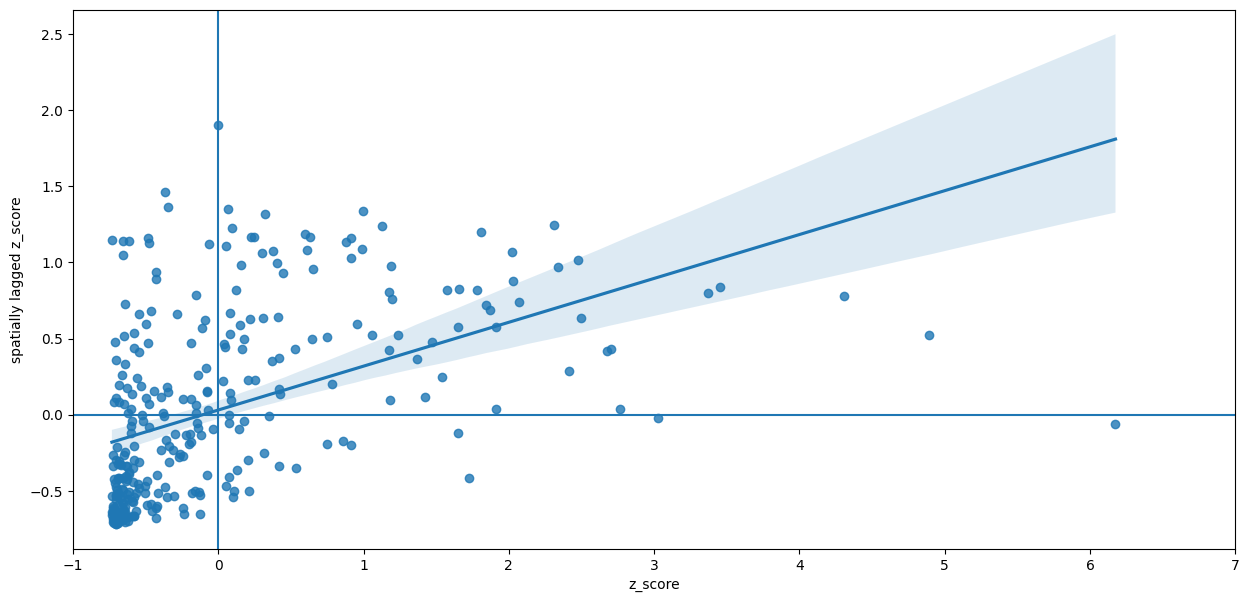

In [160]:
# plot
fig, ax = plt.subplots(1, 1, figsize=(15, 7))
sns.regplot(x = "z_score", y = "spatial_lag", data = traffic_spatial_lags_df, ax = ax)
ax.axhline(0.0)
ax.axvline(0.0)

x_min = math.floor(traffic_spatial_lags_df["z_score"].min())
x_max = math.ceil(traffic_spatial_lags_df["z_score"].max())

ax.set_xlim(x_min, x_max)
ax.set_xlabel("z_score")
ax.set_ylabel("spatially lagged z_score");

In [161]:
gmi_results = compute_Global_Moran_I_using_H3(gdf_prepared = traffic_prepared_GMI_df)
print("I =", gmi_results)

I = 0.2855000962710931


P_sim = 0.001000 , we can reject H0


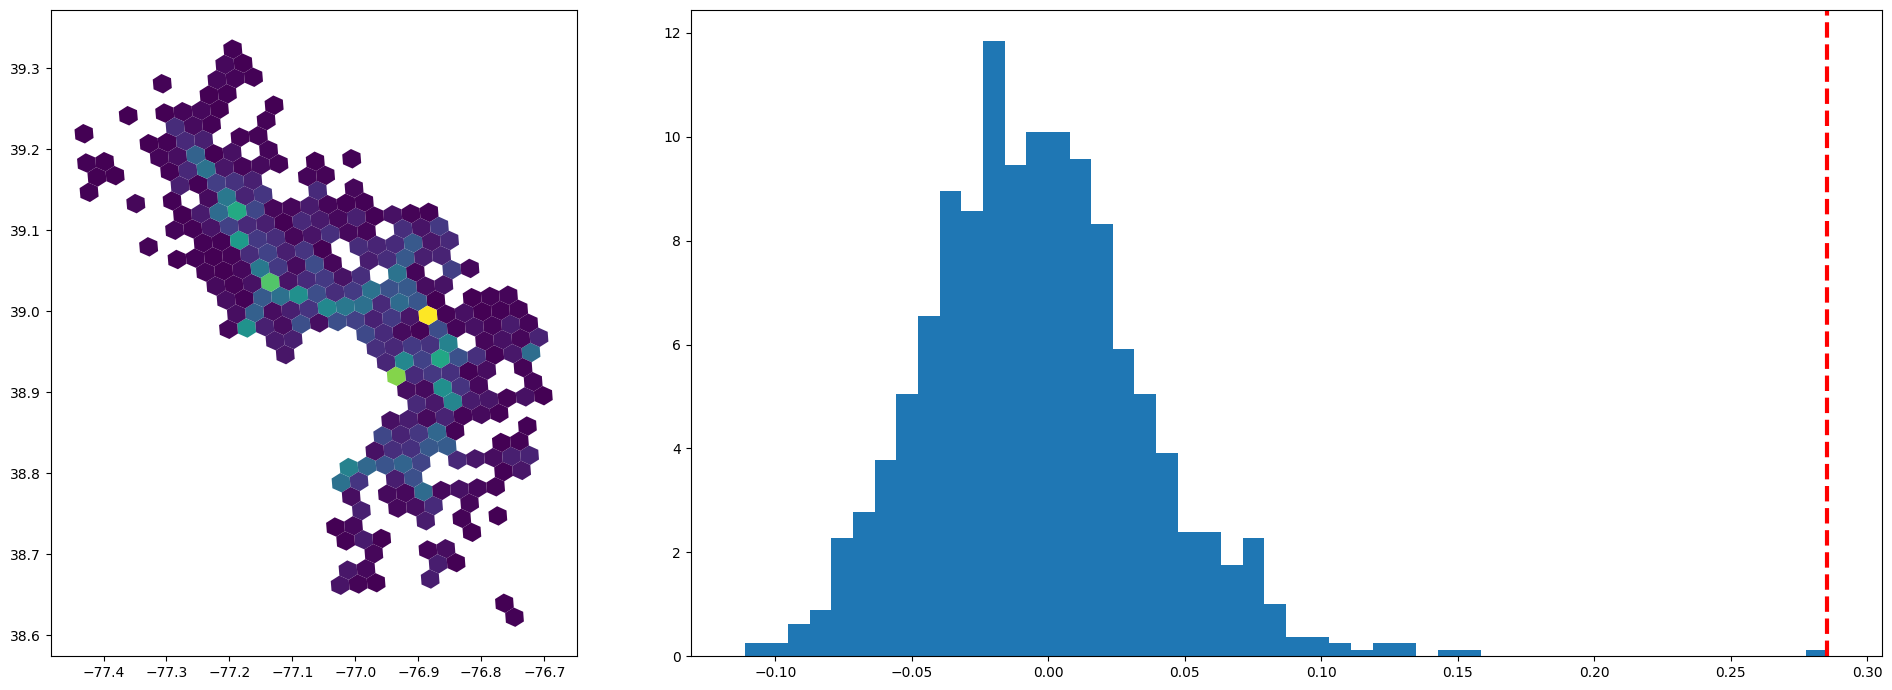

In [162]:
p_sim = reshuffle_and_recompute_GMI(gdf_prepared = traffic_prepared_GMI_df,   
                                    num_permut = 999,                            
                                    I_observed = gmi_results,
                                    alternative = "two-tailed",
                                    flag_plot = True)

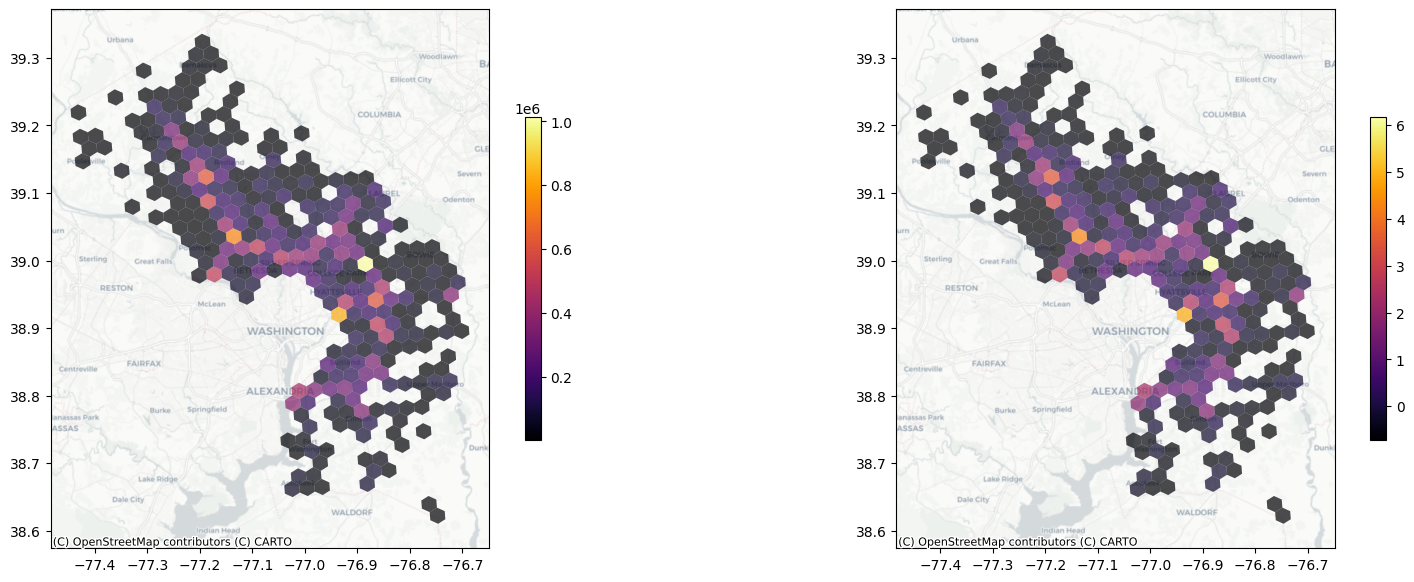

In [163]:
compare_variables(traffic_prepared_GMI_df, variables=["AAWDT_2023_sum","z_score"])

# fig, ax = plt.subplots(1, 2, figsize=(20, 7),
#                                gridspec_kw={'width_ratios': [2, 3]})

# traffic_prepared_GMI_df.plot(
#     column='AAWDT_2023',
#     figsize=(10, 10),
#     cmap='inferno',
#     alpha=0.7,
#     legend=True,
#     legend_kwds={'shrink': 0.6},
#     ax=ax[0]
# )
# cx.add_basemap(ax[0], crs=traffic_prepared_GMI_df.crs, source=cx.providers.CartoDB.Positron, zoom=10)

# traffic_prepared_GMI_df.plot(
#     column='z_score',
#     figsize=(10, 10),
#     cmap='inferno',
#     alpha=0.7,
#     legend=True,
#     legend_kwds={'shrink': 0.6},
#     ax=ax[1]
# )
# cx.add_basemap(ax[1], crs=traffic_prepared_GMI_df.crs, source=cx.providers.CartoDB.Positron, zoom=10)